In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

### Clasificador de Vinos con KNN
Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

Utilizaremos el siguiente dataset de vinos tintos extraido de Wine Quality Data Set - UCI

### Descripción de las columnas
Cada fila representa un vino. Las columnas describen su composición química:

fixed acidity, volatile acidity, citric acid

residual sugar, chlorides

free sulfur dioxide, total sulfur dioxide

density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

## Paso 1: Cargar los datos.

## EDA.

In [33]:
df =  pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/proyecto08ml.csv', sep=';')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [37]:
df['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

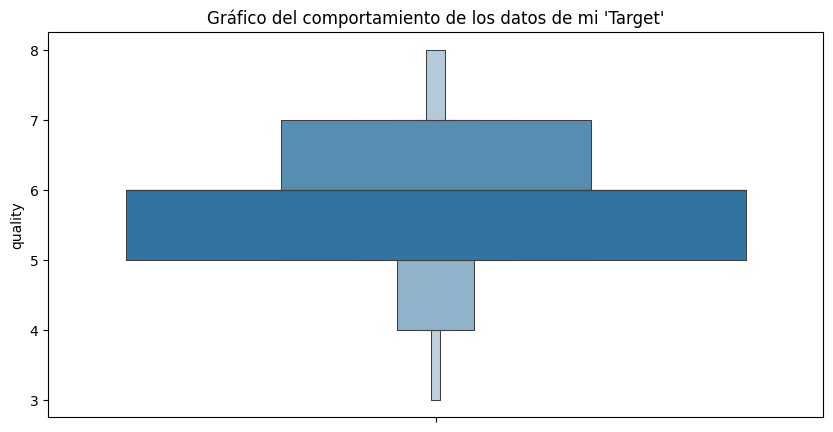

In [38]:
plt.figure(figsize=(10,5))
sns.boxenplot(data=df['quality'])
plt.title("Gráfico del comportamiento de los datos de mi 'Target'")
plt.show()

In [39]:
df["quality"] = np.select([df["quality"].isin([3, 4]),df["quality"].isin([5, 6]),df["quality"].isin([7, 8])],[0, 1, 2],default=df["quality"])


In [40]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


### Observaciones:

Calidades = {0: 'Baja calidad', 1: 'Media calidad', 2: 'Alta calidad'}

## Paso 2: Entrena el modelo KNN.

## slipt. 

In [41]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify= y, random_state=18)

In [42]:
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1202,8.6,0.420,0.39,1.8,0.068,6.0,12.0,0.99516,3.35,0.69,11.7
1463,6.9,0.630,0.01,2.4,0.076,14.0,39.0,0.99522,3.34,0.53,10.8
626,8.8,0.600,0.29,2.2,0.098,5.0,15.0,0.99880,3.36,0.49,9.1
515,8.5,0.655,0.49,6.1,0.122,34.0,151.0,1.00100,3.31,1.14,9.3
166,6.8,0.640,0.10,2.1,0.085,18.0,101.0,0.99560,3.34,0.52,10.2
...,...,...,...,...,...,...,...,...,...,...,...
139,7.8,0.560,0.19,2.0,0.081,17.0,108.0,0.99620,3.32,0.54,9.5
1323,9.1,0.360,0.39,1.8,0.060,21.0,55.0,0.99495,3.18,0.82,11.0
263,7.9,0.370,0.23,1.8,0.077,23.0,49.0,0.99630,3.28,0.67,9.3
155,7.1,0.430,0.42,5.5,0.071,28.0,128.0,0.99730,3.42,0.71,10.5


## Escalado.

In [43]:
norm_scaler = StandardScaler() 

num_variables = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
X_train_num = pd.DataFrame(norm_scaler.fit_transform(X_train[num_variables]),index=X_train.index, columns=[num_variables])
X_test_num = pd.DataFrame(norm_scaler.transform(X_test[num_variables]),index=X_test.index, columns=[num_variables])

In [44]:
X_test_num

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1202,0.163577,-0.587384,0.597622,-0.529517,-0.410200,-0.943296,-1.072329,-0.834103,0.237359,0.164486,1.161821
1463,-0.806185,0.548568,-1.328515,-0.090027,-0.250962,-0.184962,-0.230466,-0.802083,0.173225,-0.768263,0.326560
626,0.277667,0.386290,0.090744,-0.236524,0.186944,-1.038088,-0.978789,1.108426,0.301492,-1.001450,-1.251155
515,0.106533,0.683801,1.104500,2.620158,0.664659,1.710874,3.261706,2.282481,-0.019175,2.787842,-1.065542
166,-0.863229,0.602661,-0.872324,-0.309772,-0.071818,0.194205,1.702701,-0.599292,0.173225,-0.826560,-0.230281
...,...,...,...,...,...,...,...,...,...,...,...
139,-0.292781,0.169918,-0.416134,-0.383020,-0.151438,0.099414,1.920961,-0.279095,0.044958,-0.709966,-0.879928
1323,0.448802,-0.911942,0.597622,-0.529517,-0.569438,0.478581,0.268416,-0.946172,-0.852910,0.922344,0.512173
263,-0.235736,-0.857849,-0.213383,-0.529517,-0.231057,0.668164,0.081335,-0.225729,-0.211575,0.047892,-1.065542
155,-0.692095,-0.533291,0.749685,2.180668,-0.350485,1.142123,2.544564,0.307933,0.686293,0.281080,0.048139


### 

In [45]:
model = KNeighborsClassifier()
model.fit(X_train_num, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
y_pred_test = model.predict(X_test_num)
y_pred_train = model.predict(X_train_num)

y_pred_test

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2])

## Paso 3: Evalúa el rendimiento usando.

In [47]:
accuracy_score(y_test, y_pred_test)

0.8419117647058824

In [48]:
classification_report(y_test, y_pred_test, output_dict=True)

{'0': {'precision': 1.0,
  'recall': 0.07692307692307693,
  'f1-score': 0.14285714285714285,
  'support': 13.0},
 '1': {'precision': 0.86,
  'recall': 0.9684684684684685,
  'f1-score': 0.9110169491525424,
  'support': 222.0},
 '2': {'precision': 0.6190476190476191,
  'recall': 0.35135135135135137,
  'f1-score': 0.4482758620689655,
  'support': 37.0},
 'accuracy': 0.8419117647058824,
 'macro avg': {'precision': 0.8263492063492063,
  'recall': 0.46558096558096557,
  'f1-score': 0.5007166513595502,
  'support': 272.0},
 'weighted avg': {'precision': 0.8339145658263305,
  'recall': 0.8419117647058824,
  'f1-score': 0.8113570311233786,
  'support': 272.0}}

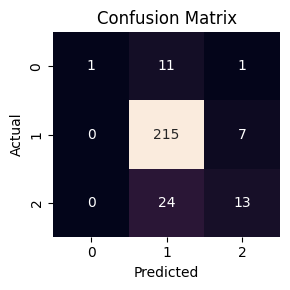

In [49]:
df_confusion = confusion_matrix(y_test, y_pred_test )
df_cm = pd.DataFrame(df_confusion)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

### Guardado del modelo. 

In [50]:
with open('/workspaces/Antonio27M-machine-learning/models/modelado-knearest-proyecto08.pkl', 'wb') as file:
    pickle.dump(model, file)

### Hiperparametrizacion. 

In [51]:
hiper_params = {'n_neighbors': [11, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35],
                'weights': ['uniform', 'distance'],
                'p': [1, 2]}

In [52]:
random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=hiper_params,
                                   n_iter=50,
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(X_train_num, y_train)
random_search.best_params_

{'weights': 'distance', 'p': 2, 'n_neighbors': 21}

In [53]:
random_search.best_score_

0.8408573965247538

In [54]:
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_num)
accuracy_score(y_test, y_pred)


0.8235294117647058

In [55]:
classification_report(y_test, y_pred, output_dict=True)

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0},
 '1': {'precision': 0.8404669260700389,
  'recall': 0.972972972972973,
  'f1-score': 0.9018789144050104,
  'support': 222.0},
 '2': {'precision': 0.5333333333333333,
  'recall': 0.21621621621621623,
  'f1-score': 0.3076923076923077,
  'support': 37.0},
 'accuracy': 0.8235294117647058,
 'macro avg': {'precision': 0.45793341980112406,
  'recall': 0.3963963963963964,
  'f1-score': 0.4031904073657728,
  'support': 272.0},
 'weighted avg': {'precision': 0.7585183489738307,
  'recall': 0.8235294117647058,
  'f1-score': 0.7779475528769401,
  'support': 272.0}}

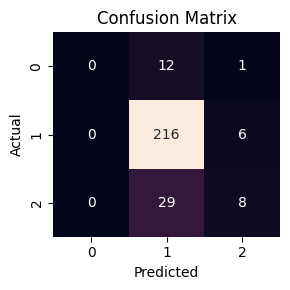

In [56]:
df_confusion = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(df_confusion)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

### Paso 4: Optimización de k.

In [57]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_num, y_train)
    
    y_pred = knn.predict(X_test_num)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

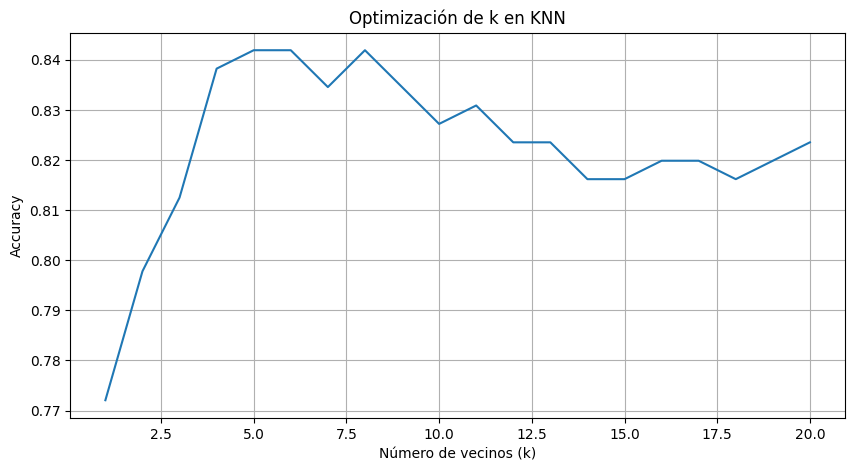

In [58]:
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy')
plt.title('Optimización de k en KNN')
plt.grid(True)
plt.show()

### Conclusiones generales. 

Según la primera matriz, me da información de que el modelo es más efectivo prediciendo los vinos de media calidad; sus extremos se le hace más difícil hacerlo. 
El k vs. accuracy me da información sobre qué k es más estable después del valor aproximado a 4; deduzco que antes de eso, los valores tienen overfitting es probable que se deban utilizar valores alrededor del k = 5 o 8. 